# Análisis de mercados de comercio electrónico con PySpark

## Objetivo

Analizar el desempeño de vendedores, logística y experiencia de clientes utilizando Apache Spark y Spark SQL sobre un dataset real de e-commerce.

## Preguntas de negocio

- ¿Qué categorías generan más ingresos?
- ¿Qué estados tienen más ventas?
- ¿Cómo afectan los retrasos a las reviews?
- ¿Qué vendedores tienen mejor desempeño?


## Tecnologías utilizadas

- PySpark
- Spark SQL
- Python
- Parquet
- Google Colab
- Pandas y matplotlib para visualizaciones

Configuración Spark

In [24]:
!pip install pyspark

In [26]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("EcommerceAnalytics") \
    .getOrCreate()

In [27]:
from pyspark.sql.functions import *
from pyspark.sql.window import Window

Leer datasets

In [39]:
customers = spark.read.csv(
    "/content/olist_customers_dataset.csv",
    header=True,
    inferSchema=True
)

orders = spark.read.csv(
    "/content/olist_orders_dataset.csv",
    header=True,
    inferSchema=True
)

In [40]:
order_items = spark.read.csv(
    "/content/olist_order_items_dataset.csv",
    header=True,
    inferSchema=True
)

geolocation = spark.read.csv(
    "/content/olist_geolocation_dataset.csv",
    header=True,
    inferSchema=True
)


products = spark.read.csv(
    "/content/olist_products_dataset.csv",
    header=True,
    inferSchema=True
)

sellers = spark.read.csv(
    "/content/olist_sellers_dataset.csv",
    header=True,
    inferSchema=True
)


In [47]:
order_payments = spark.read.csv(
    "/content/olist_order_payments_dataset.csv",
    header=True,
    inferSchema=True
)

product_category_name_translation = spark.read.csv(
    "/content/product_category_name_translation.csv",
    header=True,
    inferSchema=True
)

reviews = spark.read.csv(
    "/content/olist_order_reviews_dataset.csv",
    header=True,
    inferSchema=True
)

Exploración inicial

In [32]:
orders.show(5, truncate=False)

+--------------------------------+--------------------------------+------------+------------------------+-------------------+----------------------------+-----------------------------+-----------------------------+
|order_id                        |customer_id                     |order_status|order_purchase_timestamp|order_approved_at  |order_delivered_carrier_date|order_delivered_customer_date|order_estimated_delivery_date|
+--------------------------------+--------------------------------+------------+------------------------+-------------------+----------------------------+-----------------------------+-----------------------------+
|e481f51cbdc54678b7cc49136f2d6af7|9ef432eb6251297304e76186b10a928d|delivered   |2017-10-02 10:56:33     |2017-10-02 11:07:15|2017-10-04 19:55:00         |2017-10-10 21:25:13          |2017-10-18 00:00:00          |
|53cdb2fc8bc7dce0b6741e2150273451|b0830fb4747a6c6d20dea0b8c802d7ef|delivered   |2018-07-24 20:41:37     |2018-07-26 03:24:27|2018-07-26 14:3

Limpieza de datos

In [33]:
def null_count(df):
    return df.select([
        sum(col(c).isNull().cast("int")).alias(c)
        for c in df.columns
    ])

In [34]:
orders.select("order_id").distinct().count()

99441

In [35]:
orders.count()

99441

Construcción de tabla analítica principal

In [42]:
sales = orders.join(
    customers,
    on="customer_id",
    how="left"
)

In [43]:
sales = sales.join(
    order_items,
    on="order_id",
    how="left"
)

In [44]:
sales = sales.join(
    products,
    on="product_id",
    how="left"
)

In [45]:
sales = sales.join(
    sellers,
    on="seller_id",
    how="left"
)

In [48]:
sales = sales.join(
    reviews.select(
        "order_id",
        "review_score"
    ),
    on="order_id",
    how="left"
)

In [50]:
sales = sales.join(
    order_payments.select(
        "order_id",
        "payment_value"
    ),
    on="order_id",
    how="left"
)

In [51]:
sales.printSchema()

root
 |-- order_id: string (nullable = true)
 |-- seller_id: string (nullable = true)
 |-- product_id: string (nullable = true)
 |-- customer_id: string (nullable = true)
 |-- order_status: string (nullable = true)
 |-- order_purchase_timestamp: timestamp (nullable = true)
 |-- order_approved_at: timestamp (nullable = true)
 |-- order_delivered_carrier_date: timestamp (nullable = true)
 |-- order_delivered_customer_date: timestamp (nullable = true)
 |-- order_estimated_delivery_date: timestamp (nullable = true)
 |-- customer_unique_id: string (nullable = true)
 |-- customer_zip_code_prefix: integer (nullable = true)
 |-- customer_city: string (nullable = true)
 |-- customer_state: string (nullable = true)
 |-- order_item_id: integer (nullable = true)
 |-- shipping_limit_date: timestamp (nullable = true)
 |-- price: double (nullable = true)
 |-- freight_value: double (nullable = true)
 |-- product_category_name: string (nullable = true)
 |-- product_name_lenght: integer (nullable = true


Ingeniería de características



Tiempo de entrega

In [64]:
sales = sales.withColumn(
    "delivery_days",
    datediff(
        col("order_delivered_customer_date"),
        col("order_purchase_timestamp")
    )
)


Demora

In [62]:
sales = sales.withColumn(
    "delay_days",
    datediff(
        col("order_delivered_customer_date"),
        col("order_estimated_delivery_date")
    )
)

Categoría retraso

In [63]:
sales = sales.withColumn(
    "delivery_status",
    when(col("delay_days") > 0, "Late")
    .otherwise("On Time")
)

Guardar cache

In [ ]:
sales.cache()

¿Qué estados generan más ingresos?

In [55]:
from pyspark.sql.functions import sum, round, countDistinct, desc

In [56]:
sales_by_state = sales.groupBy(
    "customer_state"
).agg(
    round(sum("payment_value"), 2).alias("total_sales"),
    countDistinct("order_id").alias("total_orders")
).orderBy(
    desc("total_sales")
)

sales_by_state.show(10)

+--------------+-----------+------------+
|customer_state|total_sales|total_orders|
+--------------+-----------+------------+
|            SP| 7726078.35|       41746|
|            RJ| 2795615.67|       12852|
|            MG| 2351221.09|       11635|
|            RS| 1160175.66|        5466|
|            PR| 1079795.49|        5045|
|            BA|  805070.98|        3380|
|            SC|  801276.45|        3637|
|            GO|  520481.65|        2020|
|            DF|  438095.32|        2140|
|            ES|  408611.64|        2033|
+--------------+-----------+------------+
only showing top 10 rows


¿Qué categorías generan más revenue?

In [57]:
top_categories = sales.groupBy(
    "product_category_name"
).agg(
    round(sum("payment_value"), 2).alias("revenue")
).orderBy(
    desc("revenue")
)

top_categories.show(10, truncate=False)

+----------------------+----------+
|product_category_name |revenue   |
+----------------------+----------+
|cama_mesa_banho       |1743998.8 |
|beleza_saude          |1662963.59|
|informatica_acessorios|1599481.06|
|moveis_decoracao      |1443963.61|
|relogios_presentes    |1430553.48|
|esporte_lazer         |1400223.07|
|utilidades_domesticas |1097900.09|
|automotivo            |855095.68 |
|ferramentas_jardim    |840721.59 |
|cool_stuff            |781933.97 |
+----------------------+----------+
only showing top 10 rows


¿Cuánto tardan las entregas?

In [66]:
sales.select(
    round(avg("delivery_days"), 2)
    .alias("avg_delivery_days")
).show()

+-----------------+
|avg_delivery_days|
+-----------------+
|            12.43|
+-----------------+



¿Los retrasos afectan la satisfacción del cliente?

In [67]:
delay_reviews = sales.groupBy(
    "delivery_status"
).agg(
    round(avg("review_score"), 2)
    .alias("avg_review")
)

delay_reviews.show()

+---------------+----------+
|delivery_status|avg_review|
+---------------+----------+
|        On Time|      4.13|
|           Late|      2.25|
+---------------+----------+



¿Qué vendedores generan más ingresos?

In [68]:
top_sellers = sales.groupBy(
    "seller_id"
).agg(
    round(sum("payment_value"), 2).alias("revenue"),
    countDistinct("order_id").alias("orders")
).orderBy(
    desc("revenue")
)

top_sellers.show(10)

+--------------------+---------+------+
|           seller_id|  revenue|orders|
+--------------------+---------+------+
|7c67e1448b00f6e96...|512645.19|   982|
|1025f0e2d44d7041d...|312456.49|   915|
|4a3ca9315b744ce9f...| 306138.8|  1806|
|1f50f920176fa81da...|291918.98|  1404|
|53243585a1d6dc264...|284903.08|   358|
|da8622b14eb17ae28...|276578.63|  1314|
|4869f7a5dfa277a7d...|264166.12|  1132|
|955fee9216a65b617...|236414.48|  1287|
|fa1c13f2614d7b5c4...|206513.23|   585|
|7e93a43ef30c4f03f...|185134.21|   336|
+--------------------+---------+------+
only showing top 10 rows


¿Cuáles son los mejores vendedores dentro de cada estado?

In [69]:
seller_state = sales.groupBy(
    "seller_state",
    "seller_id"
).agg(
    round(sum("payment_value"), 2).alias("revenue")
)

In [70]:
window_spec = Window.partitionBy(
    "seller_state"
).orderBy(
    desc("revenue")
)

In [71]:
top_sellers_by_state = seller_state.withColumn(
    "rank",
    row_number().over(window_spec)
)

In [72]:
top_sellers_by_state.filter(
    col("rank") <= 5
).show()

+------------+--------------------+---------+----+
|seller_state|           seller_id|  revenue|rank|
+------------+--------------------+---------+----+
|        NULL|                NULL|162821.47|   1|
|          AC|4be2e7f96b4fd749d...|   299.84|   1|
|          AM|327b89b872c14d1c0...|   1258.8|   1|
|          BA|53243585a1d6dc264...|284903.08|   1|
|          BA|75d34ebb1bd0bd7dd...| 21543.25|   2|
|          BA|c72de06d72748d1a0...| 21371.82|   3|
|          BA|d03698c2efd04a549...|  12762.4|   4|
|          BA|4aba391bc3b88717c...|  8917.21|   5|
|          CE|bbf9ad41dca6603e6...|  8622.26|   1|
|          CE|dbdd0ec73a4817971...|   8174.8|   2|
|          CE|8d79c8a04e42d722a...|  4006.96|   3|
|          CE|38102b031c2a15e54...|  1552.07|   4|
|          CE|c4fabeea6e569d42d...|  1136.52|   5|
|          DF|44073f8b7e41514de...| 24605.44|   1|
|          DF|5656537e588803a55...| 14889.48|   2|
|          DF|f3b80352b986ab4d1...| 14401.67|   3|
|          DF|3c487ae8f8d7542be

¿Cómo cambian las ventas por estado y status de entrega?

In [74]:
pivot_table = sales.groupBy(
    "customer_state"
).pivot(
    "delivery_status"
).agg(
    round(sum("payment_value"), 2)
)

pivot_table.show()

+--------------+---------+----------+
|customer_state|     Late|   On Time|
+--------------+---------+----------+
|            SC| 57833.79| 743442.66|
|            RO|  2272.67|  66911.81|
|            PI| 15037.93| 122120.96|
|            AM|  1045.89|  33911.04|
|            RR|  1454.39|  11007.82|
|            GO| 25001.91| 495479.74|
|            TO|  8214.33|  64197.75|
|            MT| 11891.92| 245910.34|
|            SP|366845.21|7359233.14|
|            PB| 17017.03|  164643.7|
|            ES| 48286.47| 360325.17|
|            RS| 59159.81|1101015.85|
|            MS| 13471.94| 154198.33|
|            AL|  24025.9|  88270.57|
|            MG|101604.28|2249616.81|
|            PA| 29859.26| 233358.44|
|            BA|  85194.8| 719876.18|
|            SE| 16452.85|  74198.59|
|            PE| 33117.23| 347176.95|
|            CE| 46088.25| 303202.11|
+--------------+---------+----------+
only showing top 20 rows


In [75]:
sales.persist()

DataFrame[order_id: string, seller_id: string, product_id: string, customer_id: string, order_status: string, order_purchase_timestamp: timestamp, order_approved_at: timestamp, order_delivered_carrier_date: timestamp, order_delivered_customer_date: timestamp, order_estimated_delivery_date: timestamp, customer_unique_id: string, customer_zip_code_prefix: int, customer_city: string, customer_state: string, order_item_id: int, shipping_limit_date: timestamp, price: double, freight_value: double, product_category_name: string, product_name_lenght: int, product_description_lenght: int, product_photos_qty: int, product_weight_g: int, product_length_cm: int, product_height_cm: int, product_width_cm: int, seller_zip_code_prefix: int, seller_city: string, seller_state: string, review_score: string, payment_value: double, delay_days: int, delivery_status: string, delivery_days: int]

In [76]:
sales.explain()

== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- InMemoryTableScan [order_id#496, seller_id#524, product_id#523, customer_id#497, order_status#498, order_purchase_timestamp#499, order_approved_at#500, order_delivered_carrier_date#501, order_delivered_customer_date#502, order_estimated_delivery_date#503, customer_unique_id#475, customer_zip_code_prefix#476, customer_city#477, customer_state#478, order_item_id#522, shipping_limit_date#525, price#526, freight_value#527, product_category_name#568, product_name_lenght#569, product_description_lenght#570, product_photos_qty#571, product_weight_g#572, product_length_cm#573, product_height_cm#574, ... 9 more fields]
      +- InMemoryRelation [order_id#496, seller_id#524, product_id#523, customer_id#497, order_status#498, order_purchase_timestamp#499, order_approved_at#500, order_delivered_carrier_date#501, order_delivered_customer_date#502, order_estimated_delivery_date#503, customer_unique_id#475, customer_zip_code_prefix#476, custo

In [77]:
sales.write.mode("overwrite").parquet(
    "/content/output/sales_parquet"
)

In [78]:
sales_by_state.write.mode("overwrite").parquet(
    "/content/output/sales_by_state"
)

Visualizaciones

In [79]:
import matplotlib.pyplot as plt
import pandas as pd

In [80]:
sales_state_pd = sales_by_state.toPandas()

1. Top estados por ventas

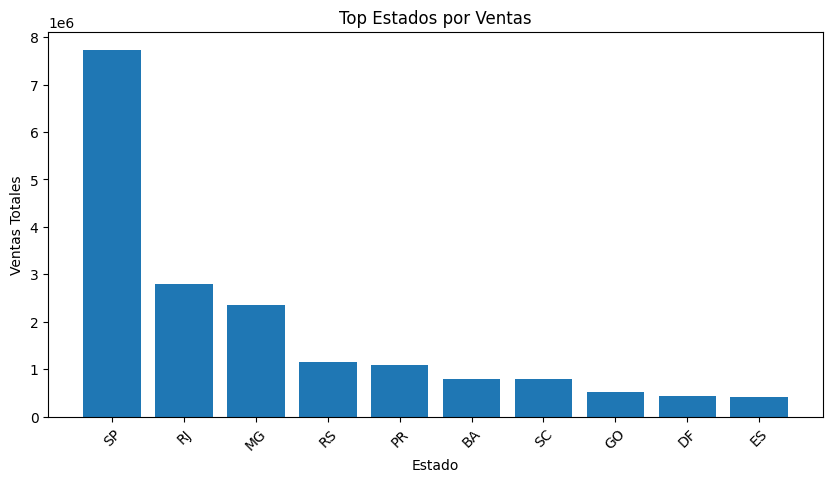

In [81]:
plt.figure(figsize=(10,5))

plt.bar(
    sales_state_pd["customer_state"][:10],
    sales_state_pd["total_sales"][:10]
)

plt.title("Top Estados por Ventas")
plt.xlabel("Estado")
plt.ylabel("Ventas Totales")

plt.xticks(rotation=45)

plt.show()

2. Categorías con más revenue

In [82]:
top_categories_pd = top_categories.limit(10).toPandas()

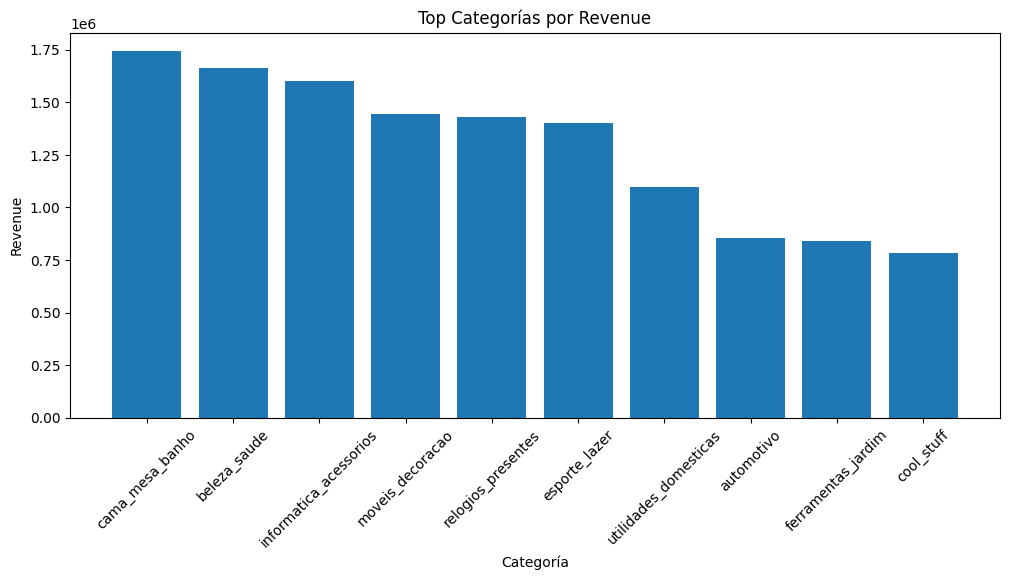

In [84]:
plt.figure(figsize=(12,5))

plt.bar(
    top_categories_pd["product_category_name"],
    top_categories_pd["revenue"]
)

plt.title("Top Categorías por Revenue")
plt.xlabel("Categoría")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.show()

3. Retrasos vs Reviews

In [85]:
delay_reviews_pd = delay_reviews.toPandas()

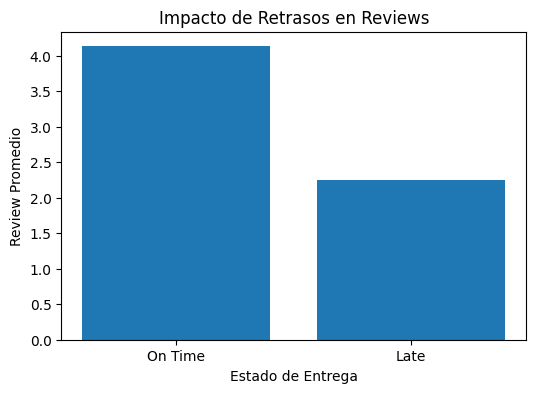

In [86]:
plt.figure(figsize=(6,4))

plt.bar(
    delay_reviews_pd["delivery_status"],
    delay_reviews_pd["avg_review"]
)

plt.title("Impacto de Retrasos en Reviews")
plt.xlabel("Estado de Entrega")
plt.ylabel("Review Promedio")

plt.show()

4. Ventas mensuales

In [92]:
sales = sales.withColumn(
    "purchase_month",
    date_format(
        col("order_purchase_timestamp"),
        "yyyy-MM"
    )
)

In [93]:
monthly_sales = sales.groupBy(
    "purchase_month"
).agg(
    round(sum("payment_value"),2)
    .alias("revenue")
).orderBy("purchase_month")

In [94]:
monthly_sales_pd = monthly_sales.toPandas()

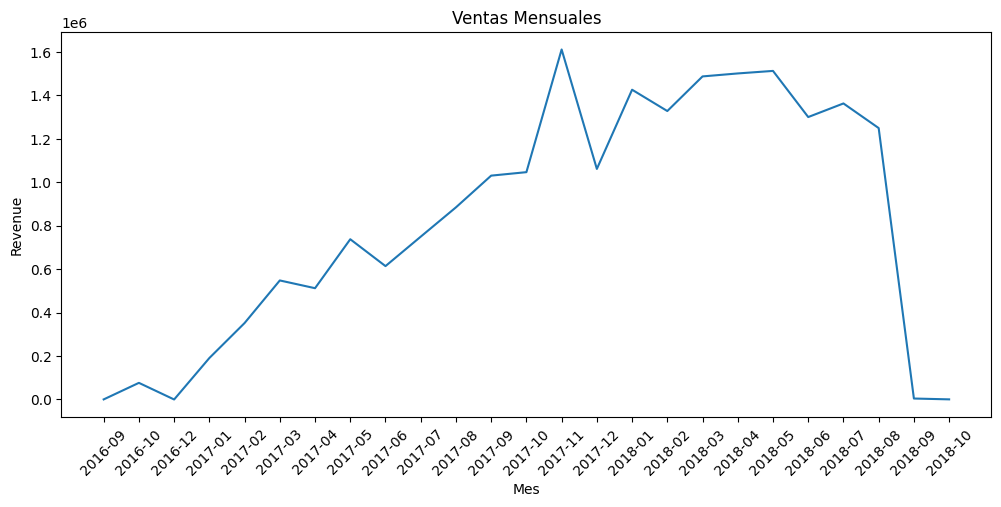

In [95]:
plt.figure(figsize=(12,5))

plt.plot(
    monthly_sales_pd["purchase_month"],
    monthly_sales_pd["revenue"]
)

plt.title("Ventas Mensuales")
plt.xlabel("Mes")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.show()